# Prognose (zusammen)
jeder Block kann unabhängig zu den anderen ausgeführt werden

## Machine Learning
Alle Kombinationsmöglichkeiten

In [3]:
# Teil 1 - Validation
import pm4py
import itertools
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score

# Hilfsfunktionen

def create_lagged_features(df, window, features, user_id_col, time_col):
    df_lagged = df.copy()
    df_lagged = df_lagged.sort_values(by=[user_id_col, time_col])

    for feat in features:
        for i in range(1, window + 1):
            col_name = f"{feat}_lag{i}"
            df_lagged[col_name] = df_lagged.groupby(user_id_col)[feat].shift(i)

    df_prepared = df_lagged.dropna().copy()
    return df_prepared

def split_train_val_test(df, user_id_col, time_col):
    df_sorted = df.sort_values(by=[user_id_col, time_col])

    test_indices = df_sorted.groupby(user_id_col).tail(1).index
    test_df = df_sorted.loc[test_indices].copy()
    remainder_df = df_sorted.drop(test_indices)

    val_indices = remainder_df.groupby(user_id_col).tail(1).index
    val_df = remainder_df.loc[val_indices].copy()

    train_df = remainder_df.drop(val_indices).copy()

    return train_df, val_df, test_df


# Daten laden und vorbereiten

print("--- Lade XES-Daten und erstelle Grund-DataFrame ---")
log = pm4py.read_xes('/Users/elias/Desktop/Uni/4. Semester : Masterarbeit/löschen (xes Dateien) 2026-05-14 5 Level - in 20%/00_xes Dateien/2026-05-08 median täglich.xes') #bei Replikation bitte eigenen Pfad einfügen
df = pm4py.convert_to_dataframe(log)
df['time:timestamp'] = pd.to_datetime(df['time:timestamp'])
df['concept:name_encoded'] = df['concept:name'].astype('category').cat.codes

# Konfiguration und Parameter
WINDOW_SIZES = [10, 7, 5, 3, 2, 1]
ALL_FEATURES = ['q1', 'concept:name_encoded', 'sound_transformed', 'q6', 'q4_inv']

TARGET_COL = 'q1'
USER_ID_COL = 'case:concept:name'
TIME_COL = 'time:timestamp'

FEATURE_COMBINATIONS = []
for r in range(1, len(ALL_FEATURES) + 1):
    for combo in itertools.combinations(ALL_FEATURES, r):
        FEATURE_COMBINATIONS.append(list(combo))

val_results_list = []

print(f"Starte Grid Search (Validation Phase): {len(WINDOW_SIZES)} Windows x {len(FEATURE_COMBINATIONS)} Feature-Kombos x 3 Modelle.\n")


# Main Loop über Windows und Features
for window in WINDOW_SIZES:
    print(f"--- Berechne Window Size: {window} ---")

    df_prepared = create_lagged_features(df, window, ALL_FEATURES, USER_ID_COL, TIME_COL)
    train_df, val_df, test_df = split_train_val_test(df_prepared, USER_ID_COL, TIME_COL)

    count_0 = (train_df[TARGET_COL] == 0).sum()
    count_1 = (train_df[TARGET_COL] == 1).sum()
    scale_pos = count_0 / count_1 if count_1 > 0 else 1

    for combo in FEATURE_COMBINATIONS:
        current_feature_cols = [col for col in df_prepared.columns if any(f"{feat}_lag" in col for feat in combo)]

        X_train = train_df[current_feature_cols]
        y_train = train_df[TARGET_COL].astype(int)

        X_val = val_df[current_feature_cols]
        y_val = val_df[TARGET_COL].astype(int)

        if X_train.shape[0] == 0 or X_val.shape[0] == 0:
            continue

        models = {
            'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
            'Random Forest': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
            'XGBoost': XGBClassifier(n_estimators=100, max_depth=5, scale_pos_weight=scale_pos, eval_metric='logloss', random_state=42)
        }

        for model_name, model in models.items():
            try:
                model.fit(X_train, y_train)
                y_pred_val = model.predict(X_val)
                y_proba_val = model.predict_proba(X_val)[:, 1]

                auc_val = roc_auc_score(y_val, y_proba_val)

                # Klasse 0 Metriken
                prec_0 = precision_score(y_val, y_pred_val, pos_label=0, zero_division=0)
                rec_0 = recall_score(y_val, y_pred_val, pos_label=0, zero_division=0)
                f1_0 = f1_score(y_val, y_pred_val, pos_label=0, zero_division=0)

                # Klasse 1 Metriken
                prec_1 = precision_score(y_val, y_pred_val, pos_label=1, zero_division=0)
                rec_1 = recall_score(y_val, y_pred_val, pos_label=1, zero_division=0)
                f1_1 = f1_score(y_val, y_pred_val, pos_label=1, zero_division=0)

                # Macro Metriken
                prec_macro = precision_score(y_val, y_pred_val, average='macro', zero_division=0)
                rec_macro = recall_score(y_val, y_pred_val, average='macro', zero_division=0)
                f1_macro = f1_score(y_val, y_pred_val, average='macro', zero_division=0)

                # Criterion Check: Alle ermittelten Werte >= 0.50?
                eval_metrics = [auc_val, prec_0, rec_0, f1_0, prec_1, rec_1, f1_1]
                is_qualified = all(m >= 0.50 for m in eval_metrics)

                val_results_list.append({
                    'Modell': model_name,
                    'Window_Size': window,
                    'Features_Anzahl': len(combo),
                    'Features_Set': ", ".join(combo),
                    'Passes_Filter': is_qualified,
                    'Support_Val_Total': len(y_val),
                    'Support_0': (y_val == 0).sum(),
                    'Support_1': (y_val == 1).sum(),
                    'Val_ROC_AUC': auc_val,
                    'Val_Precision_0_Ruhe': prec_0,
                    'Val_Recall_0_Ruhe': rec_0,
                    'Val_F1_Score_0_Ruhe': f1_0,
                    'Val_Precision_1_Tinnitus': prec_1,
                    'Val_Recall_1_Tinnitus': rec_1,
                    'Val_F1_Score_1_Tinnitus': f1_1,
                    'Val_Precision_Macro': prec_macro,
                    'Val_Recall_Macro': rec_macro,
                    'Val_F1_Score_Macro': f1_macro
                })
            except Exception as e:
                continue


# Ergebnisse auswerten und Gewinner selektieren
df_val_results = pd.DataFrame(val_results_list)

# Filtern der Modelle, die den criterion check (>= 0.50) geschafft haben
df_qualified_models = df_val_results[df_val_results['Passes_Filter'] == True].sort_values(by='Val_ROC_AUC', ascending=False)

# Export
excel_val_path = '/Users/elias/Desktop/Uni/4. Semester : Masterarbeit/Validation_Ergebnisse_Alle.xlsx' #bei Replikation bitte eigenen Pfad einfügen
excel_qualified_path = '/Users/elias/Desktop/Uni/4. Semester : Masterarbeit/Validation_Performante_Gewinner.xlsx' #bei Replikation bitte eigenen Pfad einfügen

df_val_results.to_excel(excel_val_path, index=False)
df_qualified_models.to_excel(excel_qualified_path, index=False)

print("\n")
print(f"Validation beendet!")
print(f"Gesamte getestete Konfigurationen: {len(df_val_results)}")
print(f"Performante Gewinner-Modelle (alle Metriken >= 0.5): {len(df_qualified_models)}")
print(f"Qualifizierte Gewinner gespeichert unter: {excel_qualified_path}")

--- Lade XES-Daten und erstelle Grund-DataFrame ---


parsing log, completed traces :: 100%|██████████| 2321/2321 [00:01<00:00, 1566.98it/s]


Starte Grid Search (Validation Phase): 6 Windows x 31 Feature-Kombos x 3 Modelle.

--- Berechne Window Size: 10 ---
--- Berechne Window Size: 7 ---
--- Berechne Window Size: 5 ---
--- Berechne Window Size: 3 ---
--- Berechne Window Size: 2 ---
--- Berechne Window Size: 1 ---

VALIDATION BEENDET!
Gesamte getestete Konfigurationen: 558
Performante Gewinner-Modelle (alle Metriken >= 0.5): 188
Qualifizierte Gewinner gespeichert unter: /Users/elias/Desktop/Uni/4. Semester : Masterarbeit/Validation_Performante_Gewinner.xlsx


In [4]:
# Teil 2 - Evaluation
print("--- Finale Test-Evaluierung der qualifizierten Modelle ---")

# Sicherstellen, dass qualifizierte Modelle geladen werden
if 'df_qualified_models' not in globals() or df_qualified_models.empty:
    excel_qualified_path = '/Users/elias/Desktop/Uni/4. Semester : Masterarbeit/Validation_Performante_Gewinner.xlsx' #bei Replikation bitte eigenen Pfad einfügen
    df_qualified_models = pd.read_excel(excel_qualified_path)

test_results_list = []

print(f"Anzahl zu evaluierender Top-Modelle auf dem Test Set: {len(df_qualified_models)}\n")

for idx, row in df_qualified_models.iterrows():
    model_name = row['Modell']
    window = int(row['Window_Size'])
    feature_list = [f.strip() for f in row['Features_Set'].split(',')]

    # Lags & Splitting
    df_prepared = create_lagged_features(df, window, ALL_FEATURES, USER_ID_COL, TIME_COL)
    train_df, val_df, test_df = split_train_val_test(df_prepared, USER_ID_COL, TIME_COL)

    current_feature_cols = [col for col in df_prepared.columns if any(f"{feat}_lag" in col for feat in feature_list)]

    # Für finales Test-Fitting Nutzung von Train + Val als volles Trainingsset
    train_val_df = pd.concat([train_df, val_df], ignore_index=True)

    X_train_full = train_val_df[current_feature_cols]
    y_train_full = train_val_df[TARGET_COL].astype(int)

    X_test = test_df[current_feature_cols]
    y_test = test_df[TARGET_COL].astype(int)

    count_0 = (y_train_full == 0).sum()
    count_1 = (y_train_full == 1).sum()
    scale_pos = count_0 / count_1 if count_1 > 0 else 1

    # Modell instanziieren
    if model_name == 'Logistic Regression':
        model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
    elif model_name == 'Random Forest':
        model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
    elif model_name == 'XGBoost':
        model = XGBClassifier(n_estimators=100, max_depth=5, scale_pos_weight=scale_pos, eval_metric='logloss', random_state=42)


    # Fit auf Train+Val, Predict auf Test
    model.fit(X_train_full, y_train_full)
    y_pred_test = model.predict(X_test)
    y_proba_test = model.predict_proba(X_test)[:, 1]


    # Metriken berechnen
    auc_test = roc_auc_score(y_test, y_proba_test)

    prec_0 = precision_score(y_test, y_pred_test, pos_label=0, zero_division=0)
    rec_0 = recall_score(y_test, y_pred_test, pos_label=0, zero_division=0)
    f1_0 = f1_score(y_test, y_pred_test, pos_label=0, zero_division=0)

    prec_1 = precision_score(y_test, y_pred_test, pos_label=1, zero_division=0)
    rec_1 = recall_score(y_test, y_pred_test, pos_label=1, zero_division=0)
    f1_1 = f1_score(y_test, y_pred_test, pos_label=1, zero_division=0)

    prec_macro = precision_score(y_test, y_pred_test, average='macro', zero_division=0)
    rec_macro = recall_score(y_test, y_pred_test, average='macro', zero_division=0)
    f1_macro = f1_score(y_test, y_pred_test, average='macro', zero_division=0)

    test_results_list.append({
        'Modell': model_name,
        'Window_Size': window,
        'Features_Anzahl': len(feature_list),
        'Features_Set': ", ".join(feature_list),
        'Support_Test_Total': len(y_test),
        'Support_0': (y_test == 0).sum(),
        'Support_1': (y_test == 1).sum(),
        'Test_ROC_AUC': auc_test,
        'Test_Precision_0_Ruhe': prec_0,
        'Test_Recall_0_Ruhe': rec_0,
        'Test_F1_Score_0_Ruhe': f1_0,
        'Test_Precision_1_Tinnitus': prec_1,
        'Test_Recall_1_Tinnitus': rec_1,
        'Test_F1_Score_1_Tinnitus': f1_1,
        'Test_Precision_Macro': prec_macro,
        'Test_Recall_Macro': rec_macro,
        'Test_F1_Score_Macro': f1_macro
    })


# Export
df_test_results = pd.DataFrame(test_results_list).sort_values(by='Test_ROC_AUC', ascending=False)

excel_test_path = '/Users/elias/Desktop/Uni/4. Semester : Masterarbeit/Finale_Test_Ergebnisse_TopModelle.xlsx' #bei Replikation bitte eigenen Pfad einfügen
df_test_results.to_excel(excel_test_path, index=False)

print("\n")
print(f"Die Test-Ergebnisse wurden gespeichert unter:")
print(f"Pfad: {excel_test_path}")

--- Starte finale Test-Evaluierung der qualifizierten Modelle ---
Anzahl zu evaluierender Top-Modelle auf dem Test Set: 188


FINALE TEST-EVALUATION BEENDET!
Die unverfälschten Test-Ergebnisse wurden gespeichert unter:
Pfad: /Users/elias/Desktop/Uni/4. Semester : Masterarbeit/Finale_Test_Ergebnisse_TopModelle.xlsx


## LSTM

In [1]:
# LSTM als Schleife über die performantesten ML Modelle

import os
import itertools
import numpy as np
import pandas as pd
import tensorflow as tf
import pm4py
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_fscore_support


# Konfigurationen
EVALUATION_CONFIGS = [
    {"window": 1, "features": ["q1", "concept:name_encoded", "q6", "q4_inv"]},
    {"window": 1, "features": ["q1", "concept:name_encoded", "q6"]},
    {"window": 2, "features": ["q1", "concept:name_encoded", "sound_transformed", "q4_inv"]},
    {"window": 2, "features": ["q1", "concept:name_encoded", "q6", "q4_inv"]},
    {"window": 3, "features": ["q1", "concept:name_encoded", "sound_transformed"]},
    {"window": 3, "features": ["q1", "q6"]},
    {"window": 5, "features": ["q1", "concept:name_encoded"]},
    {"window": 5, "features": ["q1", "concept:name_encoded", "q4_inv"]},
    {"window": 7, "features": ["q1"]},
    {"window": 7, "features": ["q1", "concept:name_encoded"]},
    {"window": 10, "features": ["q1", "q6"]},
    {"window": 10, "features": ["q1", "concept:name_encoded"]}
]


# Hilfsfunktionen
def create_lagged_features(df, window, features, user_id_col, time_col):
    df_lagged = df.copy()
    df_lagged = df_lagged.sort_values(by=[user_id_col, time_col])

    for feat in features:
        for i in range(1, window + 1):
            col_name = f"{feat}_lag{i}"
            df_lagged[col_name] = df_lagged.groupby(user_id_col)[feat].shift(i)

    df_prepared = df_lagged.dropna().copy()
    return df_prepared


def split_train_val_test(df, user_col, time_col):
    df_sorted = df.sort_values([user_col, time_col])

    test_indices = df_sorted.groupby(user_col).tail(1).index
    test_df = df_sorted.loc[test_indices].copy()
    remainder_df = df_sorted.drop(test_indices)

    val_indices = remainder_df.groupby(user_col).tail(1).index
    val_df = remainder_df.loc[val_indices].copy()

    train_df = remainder_df.drop(val_indices).copy()

    return train_df, val_df, test_df


# Daten laden und strukturieren
print("--- Lade Daten und initialisiere DataFrame ---")
log = pm4py.read_xes('/Users/elias/Desktop/Uni/4. Semester : Masterarbeit/löschen (xes Dateien) 2026-05-14 5 Level - in 20%/00_xes Dateien/2026-05-08 median täglich.xes')
df = pm4py.convert_to_dataframe(log)
df['time:timestamp'] = pd.to_datetime(df['time:timestamp'])
df['concept:name_encoded'] = df['concept:name'].astype('category').cat.codes

TARGET_COL = 'q1'
USER_ID_COL = 'case:concept:name'
TIME_COL = 'time:timestamp'

all_runs_results = []

print(f"\n--- Starte sequentiellen LSTM Multi-Run ({len(EVALUATION_CONFIGS)} Setups) ---")


# Loop über alle Input-Setups
for idx, config in enumerate(EVALUATION_CONFIGS, 1):
    current_window = config["window"]
    current_features = config["features"]
    n_features = len(current_features)

    print(f"\n" + "="*70)
    print(f"RUN {idx}/{len(EVALUATION_CONFIGS)}: Window={current_window} | Features={current_features}")
    print("="*70)

    # Lags erzeugen & 3-Way Split durchführen
    df_prepared_lstm = create_lagged_features(df, current_window, current_features, USER_ID_COL, TIME_COL)
    train_df, val_df, test_df = split_train_val_test(df_prepared_lstm, USER_ID_COL, TIME_COL)

    # Feature Spaltennamen zusammenbauen
    feature_cols = []
    for feat in current_features:
        for i in range(1, current_window + 1):
            feature_cols.append(f'{feat}_lag{i}')

    X_train = train_df[feature_cols]
    y_train = train_df[TARGET_COL].astype(int)

    X_val = val_df[feature_cols]
    y_val = val_df[TARGET_COL].astype(int)

    X_test = test_df[feature_cols]
    y_test = test_df[TARGET_COL].astype(int)

    if X_train.shape[0] == 0 or X_val.shape[0] == 0 or X_test.shape[0] == 0:
        print(f"Skippe Run {idx}, da Daten nach Split unvollständig sind.")
        continue

    # Skalierung (Fit nur auf Train)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)

    # 3D-Tensor Umformung & Zeit-Invertierung
    def to_lstm_tensor(X_scaled, window_size, n_feats):
        tensor = X_scaled.reshape((X_scaled.shape[0], window_size, n_feats))
        return np.flip(tensor, axis=1)

    X_train_lstm = to_lstm_tensor(X_train_scaled, current_window, n_features)
    X_val_lstm   = to_lstm_tensor(X_val_scaled, current_window, n_features)
    X_test_lstm  = to_lstm_tensor(X_test_scaled, current_window, n_features)

    # Modell-Definition
    def build_lstm_model(window, n_feats):
        model = Sequential([
            Input(shape=(window, n_feats)),
            LSTM(32, return_sequences=False),
            Dropout(0.2),
            Dense(1, activation='sigmoid')
        ])
        model.compile(
            optimizer='adam',
            loss='binary_crossentropy',
            metrics=[tf.keras.metrics.AUC(name='auc')]
        )
        return model

    model_lstm = build_lstm_model(current_window, n_features)

    # Early Stopping auf Validation set
    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )

    # Schritt 1: Training & Validierung
    history = model_lstm.fit(
        X_train_lstm, y_train,
        epochs=40,
        batch_size=32,
        validation_data=(X_val_lstm, y_val),
        callbacks=[early_stop],
        verbose=0
    )

    best_epochs = len(history.epoch) - early_stop.patience if early_stop.stopped_epoch > 0 else len(history.epoch)
    best_epochs = max(1, best_epochs)

    # Validation Metriken
    y_proba_val = model_lstm.predict(X_val_lstm, verbose=0).flatten()
    val_auc = roc_auc_score(y_val, y_proba_val)

    # Schritt 2: Re-Fit auf Train + Validation & Finale Test-Evaluation
    X_train_full = pd.concat([X_train, X_val], ignore_index=True)
    y_train_full = pd.concat([y_train, y_val], ignore_index=True)

    scaler_full = StandardScaler()
    X_train_full_scaled = scaler_full.fit_transform(X_train_full)
    X_test_final_scaled = scaler_full.transform(X_test)

    X_train_full_lstm = to_lstm_tensor(X_train_full_scaled, current_window, n_features)
    X_test_final_lstm = to_lstm_tensor(X_test_final_scaled, current_window, n_features)

    model_final = build_lstm_model(current_window, n_features)
    model_final.fit(
        X_train_full_lstm, y_train_full,
        epochs=best_epochs,
        batch_size=32,
        verbose=0
    )

    # Evaluation auf dem Test-Set
    y_proba_test = model_final.predict(X_test_final_lstm, verbose=0).flatten()
    y_pred_test = (y_proba_test >= 0.5).astype(int)

    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred_test, beta=1.0, zero_division=0)
    prec_macro, rec_macro, f1_macro, _ = precision_recall_fscore_support(y_test, y_pred_test, average='macro', zero_division=0)
    test_auc = roc_auc_score(y_test, y_proba_test)

    # Ergebnisse speichern
    all_runs_results.append({
        'Modell': 'LSTM (Deep Learning)',
        'Window_Size': current_window,
        'Features_Anzahl': n_features,
        'Features_Set': ", ".join(current_features),
        'Optimitierte_Epochen': best_epochs,
        'Support_Test_Total': len(y_test),
        'Support_0': (y_test == 0).sum(),
        'Support_1': (y_test == 1).sum(),
        'Validation_ROC_AUC': val_auc,
        'Test_ROC_AUC': test_auc,
        'Precision_0_Ruhe': precision[0],
        'Recall_0_Ruhe': recall[0],
        'F1_Score_0_Ruhe': f1[0],
        'Precision_1_Tinnitus': precision[1],
        'Recall_1_Tinnitus': recall[1],
        'F1_Score_1_Tinnitus': f1[1],
        'Precision_Macro': prec_macro,
        'Recall_Macro': rec_macro,
        'F1_Score_Macro': f1_macro
    })

    print(f"Run {idx} beendet -> Val ROC-AUC: {val_auc:.4f} | Test ROC-AUC: {test_auc:.4f} (Epochen: {best_epochs})")


# Export
df_final_lstm_grid = pd.DataFrame(all_runs_results)

excel_path_output = '/Users/elias/Desktop/Uni/4. Semester : Masterarbeit/LSTM_Multi_Run_Ergebnisse.xlsx'
df_final_lstm_grid.to_excel(excel_path_output, index=False)

print(f"Ergebnisse von {len(all_runs_results)} Konfigurationen gespeichert.")
print(f"Pfad: {excel_path_output}")

--- Lade Daten und initialisiere DataFrame ---


/Users/elias/PycharmProjects/MasterArbeit/.venv/lib/python3.12/site-packages/pm4py/utils.py:1025: UserWarning: Install the optional requirement `r4pm` to import/export files faster. `rustxes` remains supported as a fallback.
  warnings.warn(
/Users/elias/PycharmProjects/MasterArbeit/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
parsing log, completed traces :: 100%|██████████| 2321/2321 [00:01<00:00, 1666.01it/s]



--- Starte sequentiellen LSTM Multi-Run (12 Setups) ---

RUN 1/12: Window=1 | Features=['q1', 'concept:name_encoded', 'q6', 'q4_inv']
Run 1 beendet -> Val ROC-AUC: 0.7155 | Test ROC-AUC: 0.7663 (Epochen: 3)

RUN 2/12: Window=1 | Features=['q1', 'concept:name_encoded', 'q6']
Run 2 beendet -> Val ROC-AUC: 0.7160 | Test ROC-AUC: 0.7698 (Epochen: 3)

RUN 3/12: Window=2 | Features=['q1', 'concept:name_encoded', 'sound_transformed', 'q4_inv']
Run 3 beendet -> Val ROC-AUC: 0.7779 | Test ROC-AUC: 0.8102 (Epochen: 8)

RUN 4/12: Window=2 | Features=['q1', 'concept:name_encoded', 'q6', 'q4_inv']
Run 4 beendet -> Val ROC-AUC: 0.7766 | Test ROC-AUC: 0.8097 (Epochen: 1)

RUN 5/12: Window=3 | Features=['q1', 'concept:name_encoded', 'sound_transformed']
Run 5 beendet -> Val ROC-AUC: 0.8360 | Test ROC-AUC: 0.8342 (Epochen: 17)

RUN 6/12: Window=3 | Features=['q1', 'q6']
Run 6 beendet -> Val ROC-AUC: 0.8337 | Test ROC-AUC: 0.8459 (Epochen: 1)

RUN 7/12: Window=5 | Features=['q1', 'concept:name_encoded'

--- Lade Daten von XES ---


parsing log, completed traces :: 100%|██████████| 2321/2321 [00:02<00:00, 1128.37it/s]


--- Bereite Features vor (Window = 3) ---
--- Initialisiere LSTM Modell ---
--- Starte Training ---
Epoch 1/40
984/984 ━━━━━━━━━━━━━━━━━━━━ 2s 916us/step - auc: 0.8428 - loss: 0.3345 - val_auc: 0.8296 - val_loss: 0.3869
Epoch 2/40
984/984 ━━━━━━━━━━━━━━━━━━━━ 1s 751us/step - auc: 0.8632 - loss: 0.3031 - val_auc: 0.8261 - val_loss: 0.3880
Epoch 3/40
984/984 ━━━━━━━━━━━━━━━━━━━━ 1s 742us/step - auc: 0.8620 - loss: 0.3016 - val_auc: 0.8248 - val_loss: 0.3880
Epoch 4/40
984/984 ━━━━━━━━━━━━━━━━━━━━ 1s 764us/step - auc: 0.8648 - loss: 0.3001 - val_auc: 0.8286 - val_loss: 0.3899
Epoch 5/40
984/984 ━━━━━━━━━━━━━━━━━━━━ 1s 735us/step - auc: 0.8646 - loss: 0.2994 - val_auc: 0.8291 - val_loss: 0.3911
Epoch 6/40
984/984 ━━━━━━━━━━━━━━━━━━━━ 1s 727us/step - auc: 0.8634 - loss: 0.2997 - val_auc: 0.8269 - val_loss: 0.3893
--- Generiere Lernkurve ---


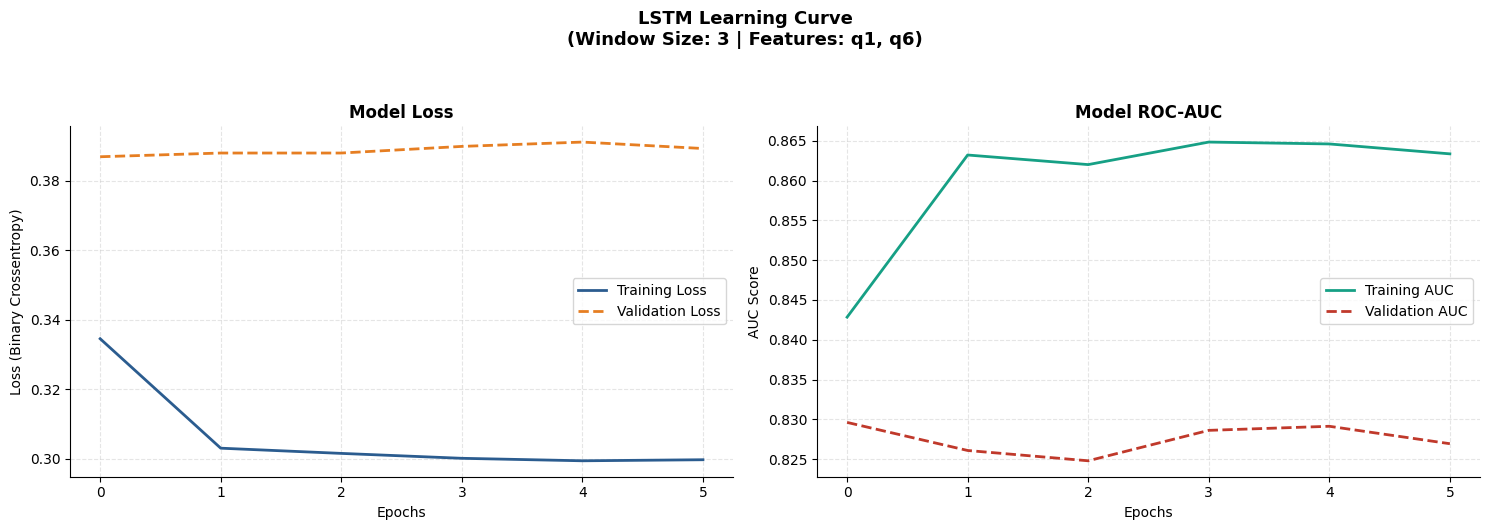

In [4]:
'''
# Abbildung für MA
# Entwicklung LSTM über die Epochen hinweg / Visualisierung der Lernkurve

import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pm4py

# Globalen Plot-Style auf Weiß setzen
plt.style.use('default')

# Parameter fürs gewünschte Modell definieren
WINDOW_SIZE = 3
FEATURES = ["q1", "q6"]
N_FEATURES = len(FEATURES)

TARGET_COL = 'q1'
USER_ID_COL = 'case:concept:name'
TIME_COL = 'time:timestamp'


# Hilfsfunktionen
def create_lagged_features(df, window, features, user_id_col, time_col):
    df_lagged = df.copy()
    df_lagged = df_lagged.sort_values(by=[user_id_col, time_col])

    for feat in features:
        for i in range(1, window + 1):
            col_name = f"{feat}_lag{i}"
            df_lagged[col_name] = df_lagged.groupby(user_id_col)[feat].shift(i)

    df_prepared = df_lagged.dropna().copy()
    return df_prepared


def split_train_val_test(df, user_col, time_col):
    df_sorted = df.sort_values([user_col, time_col])

    test_indices = df_sorted.groupby(user_col).tail(1).index
    test_df = df_sorted.loc[test_indices].copy()
    remainder_df = df_sorted.drop(test_indices)

    val_indices = remainder_df.groupby(user_col).tail(1).index
    val_df = remainder_df.loc[val_indices].copy()

    train_df = remainder_df.drop(val_indices).copy()

    return train_df, val_df, test_df


# Daten laden und strukturieren
print("--- Lade Daten von XES ---")
file_path = '/Users/elias/Desktop/Uni/4. Semester : Masterarbeit/löschen (xes Dateien) 2026-05-14 5 Level - in 20%/00_xes Dateien/2026-05-08 median täglich.xes'
log = pm4py.read_xes(file_path)
df = pm4py.convert_to_dataframe(log)

df['time:timestamp'] = pd.to_datetime(df['time:timestamp'])
df['concept:name_encoded'] = df['concept:name'].astype('category').cat.codes

# Feature Lags generieren & 3-Way Split durchführen
print("--- Bereite Features vor (Window = 3) ---")
df_prepared_lstm = create_lagged_features(df, WINDOW_SIZE, FEATURES, USER_ID_COL, TIME_COL)
train_df, val_df, test_df = split_train_val_test(df_prepared_lstm, USER_ID_COL, TIME_COL)

# Feature Spaltennamen dynamisch erzeugen
feature_cols = []
for feat in FEATURES:
    for i in range(1, WINDOW_SIZE + 1):
        feature_cols.append(f'{feat}_lag{i}')

X_train_raw = train_df[feature_cols]
y_train = train_df[TARGET_COL].astype(int)

X_val_raw = val_df[feature_cols]
y_val = val_df[TARGET_COL].astype(int)

# Skalierung (Fit nur auf Train)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_val_scaled = scaler.transform(X_val_raw)

# 3D-Tensor Umformung & Zeit-Invertierung für LSTM
def to_lstm_tensor(X_scaled, window_size, n_feats):
    tensor = X_scaled.reshape((X_scaled.shape[0], window_size, n_feats))
    return np.flip(tensor, axis=1)

X_train_lstm = to_lstm_tensor(X_train_scaled, WINDOW_SIZE, N_FEATURES)
X_val_lstm   = to_lstm_tensor(X_val_scaled, WINDOW_SIZE, N_FEATURES)


# LSTM Modellbau und Training
print("--- Initialisiere LSTM Modell ---")
model_lstm = Sequential([
    Input(shape=(WINDOW_SIZE, N_FEATURES)),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model_lstm.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.AUC(name='auc')]
)

# Early Stopping definieren
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

print("--- Starte Training ---")
history_obj = model_lstm.fit(
    X_train_lstm, y_train,
    epochs=40,
    batch_size=32,
    validation_data=(X_val_lstm, y_val), # SAUBERE VALIDIERUNG (NICHT TEST SET!)
    callbacks=[early_stop],
    verbose=1
)


# Visualisierung der Lernkurve
print("--- Generiere Lernkurve ---")
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Loss-Entwicklung (Train vs. Val)
ax[0].plot(history_obj.history['loss'], label='Training Loss', color='#2b5c8f', linewidth=2)
ax[0].plot(history_obj.history['val_loss'], label='Validation Loss', color='#e67e22', linewidth=2, linestyle='--')
ax[0].set_title('Model Loss', fontsize=12, fontweight='bold')
ax[0].set_xlabel('Epochs', fontsize=10)
ax[0].set_ylabel('Loss (Binary Crossentropy)', fontsize=10)
ax[0].grid(True, linestyle='--', alpha=0.5, color='#cccccc')
ax[0].legend(frameon=True, facecolor='white')
ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)

# Plot 2: AUC-Entwicklung (Train vs. Val)
ax[1].plot(history_obj.history['auc'], label='Training AUC', color='#16a085', linewidth=2)
ax[1].plot(history_obj.history['val_auc'], label='Validation AUC', color='#c0392b', linewidth=2, linestyle='--')
ax[1].set_title('Model ROC-AUC', fontsize=12, fontweight='bold')
ax[1].set_xlabel('Epochs', fontsize=10)
ax[1].set_ylabel('AUC Score', fontsize=10)
ax[1].grid(True, linestyle='--', alpha=0.5, color='#cccccc')
ax[1].legend(frameon=True, facecolor='white')
ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)

plt.suptitle('LSTM Learning Curve\n(Window Size: 3 | Features: q1, q6)', fontsize=13, fontweight='bold', y=1.05)
plt.tight_layout()

plt.show()
#'''

In [ ]:
'''
# LSTM Feature Importance (Permutation Drop)

import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score

print("\n--- Starte Permutation Feature Importance für das LSTM ---")


# Ausgangs-Score berechnen
y_proba_baseline = model_lstm.predict(X_test_lstm, verbose=0)

if len(y_proba_baseline.shape) > 1 and y_proba_baseline.shape[1] == 2:
    y_proba_baseline = y_proba_baseline[:, 1]
else:
    y_proba_baseline = y_proba_baseline.flatten()

baseline_auc = roc_auc_score(y_test, y_proba_baseline)
print(f" -> Echter ROC-AUC des Modells auf dem Test-Set: {baseline_auc:.4f}")



# Permutation Schleife (Wir testen jedes Feature einzeln)
# Die Feature-Namen in der exakten Reihenfolge, wie sie in X_test_lstm stecken
feature_names = ['q1', 'concept:name_encoded', 'q6']
importance_results = []

for feature_idx, feat_name in enumerate(feature_names):
    print(f" -> Analysiere Feature '{feat_name}' (Index {feature_idx})...")

    # Eine tiefe Kopie des Testsets erstellen, um die Originaldaten nicht zu zerstören
    X_test_permuted = np.copy(X_test_lstm)

    # -----------------------------------------------------------------
    # Wir zerstören die zeitliche Sequenz NUR für dieses eine Feature.
    # Da X die Form (User-Tage, Zeitschritte, Features) hat, shuffeln wir
    # die komplette User-Historie über alle Zeilen hinweg für diesen Index.
    # -----------------------------------------------------------------
    # Wir extrahieren die komplette 2D-Matrix (Zeilen x 5 Zeitschritte) dieses Features
    feature_matrix = X_test_permuted[:, :, feature_idx]

    # Generiere einen zufälligen Index-Permutationsvektor
    shuffled_indices = np.random.permutation(len(feature_matrix))

    # Ersetze die originale Feature-Matrix durch die durchmischte Version
    X_test_permuted[:, :, feature_idx] = feature_matrix[shuffled_indices]

    # -----------------------------------------------------------------
    # Prädikation und Score-Einbruch messen
    # -----------------------------------------------------------------
    y_proba_permuted = model_lstm.predict(X_test_permuted, verbose=0)
    if len(y_proba_permuted.shape) > 1 and y_proba_permuted.shape[1] == 2:
        y_proba_permuted = y_proba_permuted[:, 1]
    else:
        y_proba_permuted = y_proba_permuted.flatten()

    permuted_auc = roc_auc_score(y_test, y_proba_permuted)

    # Die "Wichtigkeit" ist die Differenz: Wie viel schlechter wird das Modell ohne dieses Feature?
    importance_drop = baseline_auc - permuted_auc

    importance_results.append({
        'Feature': feat_name,
        'ROC_AUC_nach_Shuffle': permuted_auc,
        'Importance_Drop': max(0.0, importance_drop) # Keine negativen Drops zulassen
    })


# Auswertung und Darstellung
df_importance = pd.DataFrame(importance_results)
df_importance = df_importance.sort_values(by='Importance_Drop', ascending=False).reset_index(drop=True)

print("\n" + "="*60)
print("LSTM FEATURE IMPORTANCE (PERMUTATION DROP):")
print("="*60)
for idx, row in df_importance.iterrows():
    print(f"Platz {idx+1}: {row['Feature']:<22} | Drop im ROC-AUC: {row['Importance_Drop']:.4f} (Rest-AUC: {row['ROC_AUC_nach_Shuffle']:.4f})")
print("="*60)
print("Je höher der 'Drop im ROC-AUC', desto wichtiger ist das Feature für das LSTM!")
#'''

## Hiatus-Heuristik

In [1]:
import pandas as pd
import numpy as np
import pm4py
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_fscore_support

print("--- Starte isolierte Evaluation der Hiatus-Heuristik (Recency Baseline) ---")


# Parameter und Daten laden
TARGET_COL = 'q1'
USER_ID_COL = 'case:concept:name'
TIME_COL = 'time:timestamp'
HIATUS_TIMES = [1, 2, 3, 5, 7, 10]  # Alle gewünschten T-Werte

# Daten in eine lokale Variable laden, um Konflikte zu vermeiden
log_hiatus = pm4py.read_xes('/Users/elias/Desktop/Uni/4. Semester : Masterarbeit/2026-05-14 5 Level - in 20%/00_xes Dateien/2026-05-08 median täglich.xes') #bei Replikation bitte eigenen Pfad einfügen
df_hiatus_base = pm4py.convert_to_dataframe(log_hiatus)
df_hiatus_base['time:timestamp'] = pd.to_datetime(df_hiatus_base['time:timestamp'])
df_hiatus_base = df_hiatus_base.sort_values(by=[USER_ID_COL, TIME_COL])


# Generiere maximal benötigte Lags (Bis t=10)
MAX_HIATUS = max(HIATUS_TIMES)
all_lag_cols = []

for i in range(1, MAX_HIATUS + 1):
    col_name = f"{TARGET_COL}_lag{i}"
    df_hiatus_base[col_name] = df_hiatus_base.groupby(USER_ID_COL)[TARGET_COL].shift(i)
    all_lag_cols.append(col_name)

# Bereinigen: Nur Zeilen behalten, die die volle Historie UND ein gültiges Target haben
cols_to_clean = all_lag_cols + [TARGET_COL]
df_hiatus_prepared = df_hiatus_base.dropna(subset=cols_to_clean).copy()


# Zeitbasierter Split (Letztes Event pro User)
# Test-Set: Das jeweils letzte Event pro Patient
test_df_hiatus = df_hiatus_prepared.groupby(USER_ID_COL).last().reset_index()

y_test = test_df_hiatus[TARGET_COL].astype(int)


# Evaluation der einzelnen Zeitschritte
hiatus_results = []

for w in HIATUS_TIMES:
    # Erstelle die Liste aller relevanten Lag-Spalten für das aktuelle Zeitfenster W
    # Z.B. für w=3 -> ['q1_lag1', 'q1_lag2', 'q1_lag3']
    all_lags_up_to_W = [f"{TARGET_COL}_lag{i}" for i in range(1, w + 1)]

    # Die Heuristik prüft das MAXIMUM über das gesamte Fenster W (Logisches ODER)
    # Wenn mindestens eine 1 in den Lags vorkommt, liefert .max(axis=1) eine 1
    y_pred = test_df_hiatus[all_lags_up_to_W].max(axis=1).astype(int)

    # Da es eine Heuristik ist, nutzen wir den Maximum-Wert direkt als Wahrscheinlichkeit für den AUC
    y_proba = test_df_hiatus[all_lags_up_to_W].max(axis=1).astype(float)

    # Metriken berechnen
    auc = roc_auc_score(y_test, y_proba)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, beta=1.0, zero_division=0)

    hiatus_results.append({
        'Modell': f'Hiatus-Heuristik (W={w})',
        'Window_Size': w,
        'Features_Anzahl': len(all_lags_up_to_W),
        'Features_Set': f"max({', '.join(all_lags_up_to_W)})",
        'Support_Test_Total': len(y_test),
        'Support_0': (y_test == 0).sum(),
        'Support_1': (y_test == 1).sum(),
        'ROC_AUC': auc,
        'Precision_0_Ruhe': precision[0],
        'Recall_0_Ruhe': recall[0],
        'F1_Score_0_Ruhe': f1[0],
        'Precision_1_Tinnitus': precision[1],
        'Recall_1_Tinnitus': recall[1],
        'F1_Score_1_Tinnitus': f1[1],
        'Top_10_Features': 'N/A (Baseline Heuristik)'
    })


# Speichern und Ausgabe
df_hiatus_res = pd.DataFrame(hiatus_results)

excel_path = '/Users/elias/Desktop/Uni/4. Semester : Masterarbeit/Hiatus_Heuristik_Ergebnisse.xlsx'
df_hiatus_res.to_excel(excel_path, index=False)

print("\n==================================================")
print("HIATUS HEURISTIK ERGEBNISSE (ÜBERSICHT):")
print("==================================================")
print(df_hiatus_res[['Modell', 'ROC_AUC', 'Precision_0_Ruhe', 'Recall_0_Ruhe', 'F1_Score_0_Ruhe']])
print(f"\nExcel erfolgreich gespeichert unter: {excel_path}")
print("==================================================")

--- Starte isolierte Evaluation der Hiatus-Heuristik (Recency Baseline) ---


/Users/elias/PycharmProjects/MasterArbeit/.venv/lib/python3.12/site-packages/pm4py/utils.py:1025: UserWarning: Install the optional requirement `r4pm` to import/export files faster. `rustxes` remains supported as a fallback.
  warnings.warn(
/Users/elias/PycharmProjects/MasterArbeit/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
parsing log, completed traces :: 100%|██████████| 2321/2321 [00:01<00:00, 1627.79it/s]



HIATUS HEURISTIK ERGEBNISSE (ÜBERSICHT):
                    Modell   ROC_AUC  Precision_0_Ruhe  Recall_0_Ruhe  \
0   Hiatus-Heuristik (W=1)  0.806212          0.616883       0.719697   
1   Hiatus-Heuristik (W=2)  0.733939          0.723404       0.515152   
2   Hiatus-Heuristik (W=3)  0.692727          0.805970       0.409091   
3   Hiatus-Heuristik (W=5)  0.637576          0.844444       0.287879   
4   Hiatus-Heuristik (W=7)  0.624242          0.871795       0.257576   
5  Hiatus-Heuristik (W=10)  0.607121          0.906250       0.219697   

   F1_Score_0_Ruhe  
0         0.664336  
1         0.601770  
2         0.542714  
3         0.429379  
4         0.397661  
5         0.353659  

Excel erfolgreich gespeichert unter: /Users/elias/Desktop/Uni/4. Semester : Masterarbeit/Hiatus_Heuristik_Ergebnisse.xlsx


## Multi-Window Set
(als Ergänzung)

In [ ]:
# kommt mit Pro und Contra
# Pro: Stress kann kurzfristigen Effekt haben, Lautstärke dagegen einen langfristigen
# Deshalb unterschiedliche Windows Sizes
# Contra: Data Leakage. Das kombinierte Modell hat einen anderen Input als die "klassischen" ML Modelle. Es weiß bereits, wo das optimale Window Size liegt.
# Man kann die Modelle also nicht 1:1 gegeneinander bewerten.

In [10]:
import itertools
import numpy as np
import pandas as pd
import pm4py
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score


# Hilfsfunktionen (für den zeitbasierten Split)
def split_by_last_event(df, user_id_col, time_col):
    """
    Sortiert die Daten chronologisch und trennt das jeweils allerletzte Event
    pro Patient für das Test-Set ab. Alle vorherigen Tage landen im Train-Set.
    """
    df_sorted = df.sort_values(by=[user_id_col, time_col])

    # Letztes Event pro User extrahieren
    test_df = df_sorted.groupby(user_id_col).last().reset_index()

    # Train-Set bilden (alle Zeilen außer den Test-Indizes)
    test_indices = df_sorted.groupby(user_id_col).tail(1).index
    train_df = df_sorted.drop(test_indices)

    return train_df, test_df



# Daten laden und vorbereiten
print("--- Lade Daten und initialisiere Basis-DataFrame ---")

log = pm4py.read_xes('/Users/elias/Desktop/Uni/4. Semester : Masterarbeit/2026-05-11 "q-kNN" täglich.xes') #bei Replikation bitte eigenen Pfad einfügen
df = pm4py.convert_to_dataframe(log)
df['time:timestamp'] = pd.to_datetime(df['time:timestamp'])

# Kategoriale Prozesszustände in numerische Werte codieren
df['concept:name_encoded'] = df['concept:name'].astype('category').cat.codes



# Konfiguration: optimale Fenster je Feature eintragen


# Nach Analyse die exakte Anzahl an Lags pro Feature eintragen

OPTIMAL_WINDOWS = {
    'q1': 10,                 # <-- Tinnitus-Historie
    'q6': 5,                  # <-- Stress-Wert
    #'q4_inv': 5,              # <-- Stimmung
    'concept:name_encoded': 5 # <-- Score
    # 'sound_transformed': 2  # <-- Sound
}

TARGET_COL = 'q1'
USER_ID_COL = 'case:concept:name'
TIME_COL = 'time:timestamp'



# Dynamische Generierung und Synchronisation der Lags
print("\n--- Generiere maßgeschneiderte Multi-Window-Struktur ---")

# Wir arbeiten auf einer neuen Kopie, um Seiteneffekte zu vermeiden
df_multi_build = df.copy()
df_multi_build = df_multi_build.sort_values(by=[USER_ID_COL, TIME_COL])

all_generated_lag_cols = []

# Erstelle die Lags (noch OHNE Zeilen zu löschen, damit alles synchron bleibt)
for feat, target_window in OPTIMAL_WINDOWS.items():
    print(f" -> Berechne {target_window} Lags für Feature: '{feat}'")
    for i in range(1, target_window + 1):
        col_name = f"{feat}_lag{i}"
        df_multi_build[col_name] = df_multi_build.groupby(USER_ID_COL)[feat].shift(i)
        all_generated_lag_cols.append(col_name)

# Synchronisiertes Bereinigen: Löscht Zeilen, wenn Lags ODER das Target NaNs enthalten
cols_to_clean = all_generated_lag_cols + [TARGET_COL]
df_multi_prepared = df_multi_build.dropna(subset=cols_to_clean).copy()

# Zeitbasierter Train-Test-Split auf den synchronisierten Daten
print(" -> Führe zeitbasierten Train-Test-Split durch...")
train_df_multi, test_df_multi = split_by_last_event(df_multi_prepared, USER_ID_COL, TIME_COL)

# Aufteilen in Prädiktoren (X) und Zielvariable (y)
X_train_multi = train_df_multi[all_generated_lag_cols]
y_train = train_df_multi[TARGET_COL].astype(int)

X_test_multi = test_df_multi[all_generated_lag_cols]
y_test = test_df_multi[TARGET_COL].astype(int)

print(f"\nDaten erfolgreich vorbereitet!")
print(f" - X_train_multi Dimensionen: {X_train_multi.shape}")
print(f" - y_train Dimensionen:       {y_train.shape}")
print(f"Gesamtanzahl Prädiktoren im Modell: {X_train_multi.shape[1]} Spalten.")



# Modelltraining (hier XGBoost)
print("\n--- Trainiere XGBoost auf Multi-Window-Struktur ---")

# Klassenungleichgewicht berechnen für die scale_pos_weight
count_0 = (y_train == 0).sum()
count_1 = (y_train == 1).sum()
scale_pos = count_0 / count_1 if count_1 > 0 else 1

# Modell initialisieren
model_multi = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    scale_pos_weight=scale_pos,
    eval_metric='logloss',
    random_state=42
)

# Training starten
model_multi.fit(X_train_multi, y_train)



# Evaluation
# Vorhersagen und Wahrscheinlichkeiten berechnen
y_pred = model_multi.predict(X_test_multi)
y_proba = model_multi.predict_proba(X_test_multi)[:, 1]

print("\n" + "="*60)
print("ERGEBNIS DES MULTI-WINDOW XGBOOST MODELLS:")
print("="*60)
print(classification_report(y_test, y_pred, zero_division=0))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}")
print("="*60)

--- Lade Daten und initialisiere Basis-DataFrame ---


parsing log, completed traces :: 100%|██████████| 2321/2321 [00:01<00:00, 1369.01it/s]



--- Generiere maßgeschneiderte Multi-Window-Struktur ---
 -> Berechne 10 Lags für Feature: 'q1'
 -> Berechne 5 Lags für Feature: 'q6'
 -> Berechne 5 Lags für Feature: 'concept:name_encoded'
 -> Führe zeitbasierten Train-Test-Split durch...

Daten erfolgreich vorbereitet!
 - X_train_multi Dimensionen: (30697, 20)
 - y_train Dimensionen:       (30697,)
Gesamtanzahl Prädiktoren im Modell: 20 Spalten.

--- Trainiere XGBoost auf Multi-Window-Struktur ---

ERGEBNIS DES MULTI-WINDOW XGBOOST MODELLS:
              precision    recall  f1-score   support

           0       0.48      0.84      0.61       131
           1       0.95      0.78      0.86       533

    accuracy                           0.79       664
   macro avg       0.72      0.81      0.73       664
weighted avg       0.86      0.79      0.81       664

ROC-AUC Score: 0.8867


# Prognose (einzeln)
perfekt zur graphischen Ausgabe der Lags oder Confusion Matrix

nur ML Modelle (Train-Test und kein Train-Validation-Test Split)

## Vorbereitung für Modelle

In [1]:
#'''
# Bibliotheken laden
import pm4py
import pandas as pd
from xgboost import XGBClassifier
from xgboost import plot_importance
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
#'''

In [6]:
#'''
# Daten laden
log = pm4py.read_xes('/Users/elias/Desktop/Uni/4. Semester : Masterarbeit/2026-05-14 5 Level - in 20%/00_xes Dateien/2026-05-08 median täglich.xes') #bei Replikation bitte eigenen Pfad einfügen
df = pm4py.convert_to_dataframe(log)
df['time:timestamp'] = pd.to_datetime(df['time:timestamp'])

#'''

parsing log, completed traces :: 100%|██████████| 2321/2321 [00:01<00:00, 1690.17it/s]


In [7]:
#'''
# Konvertiere concept:name / score in Zahlen, bevor das Modell trainiert wird
df['concept:name_encoded'] = df['concept:name'].astype('category').cat.codes
#'''

In [12]:
#'''
# Vorbereitung fürs Modell

# Konfiguration
WINDOW_SIZE = 10 # wie viele Einträge der Vergangenheit sollen beachtet werden? Die letzten X Einträge.
FEATURES_TO_LAG = ['q1', 'q6'] #'concept:name_encoded', 'q4_inv', 'sound_transformed',  Welche Spalten sollen in die Historie einfließen?
TARGET_COL = 'q1'
USER_ID_COL = 'case:concept:name'
TIME_COL = 'time:timestamp'

# Erstellt für jeden User die letzten N Schritte als Features.
def create_lagged_features(df, window_size, features_to_lag, user_col, time_col):

    # Daten sortieren
    df = df.sort_values([user_col, time_col])
    df_result = df.copy()

    # Schleife über die in FEATURES_TO_LAG definierten Spalten
    for feature in features_to_lag:
        for i in range(1, window_size + 1):
            # Erstellt z.B. 'q1_lag1', 'sound_norm_lag1', 'score_lag1' usw.
            df_result[f'{feature}_lag{i}'] = df.groupby(user_col)[feature].shift(i)

    # Entfernen der Zeilen mit unvollständiger Historie
    df_result = df_result.dropna()

    return df_result


df_prepared = create_lagged_features(df, WINDOW_SIZE, FEATURES_TO_LAG, USER_ID_COL, TIME_COL)
#'''

In [13]:
#'''
# Teilt die Daten so, dass der letzte Eintrag jedes Users im Testset landet und der Rest im Training.
def split_by_last_event(df, user_col, time_col):

    # Sortieren
    df = df.sort_values([user_col, time_col])

    # Den letzten Eintrag pro User markieren
    last_indices = df.groupby(user_col).tail(1).index

    # Splitten
    test_df = df.loc[last_indices]
    train_df = df.drop(last_indices)

    return train_df, test_df
#'''

In [14]:
#'''
# Train Test Split

# Split in Training und Test
train_df, test_df = split_by_last_event(df_prepared, USER_ID_COL, TIME_COL)

# Features und Ziel definieren
# Alle Spalten, die 'lag' im Namen haben, sind unsere Input-Features
feature_cols = [col for col in df_prepared.columns if 'lag' in col]

X_train = train_df[feature_cols]
y_train = train_df[TARGET_COL]

X_test = test_df[feature_cols]
y_test = test_df[TARGET_COL]

print(f"Trainingsdaten: {X_train.shape[0]} Zeilen")
print(f"Testdaten: {X_test.shape[0]} Zeilen")
#'''

Trainingsdaten: 26341 Zeilen
Testdaten: 606 Zeilen


## Logistische Regession

In [11]:
#'''
# Baseline Modell das geschlagen werden muss / sollte

# Initialisierung
# 'balanced' passt die Gewichte automatisch an die Klassenverteilung an
model_lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)

# Training
model_lr.fit(X_train, y_train)

# Vorhersage auf dem Testset
y_pred_lr = model_lr.predict(X_test)
y_proba_lr = model_lr.predict_proba(X_test)[:, 1]

# Evaluation
print("Logistische Regession Klassifikationsbericht:")
print(classification_report(y_test, y_pred_lr))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba_lr):.4f}")
#'''

Logistische Regession Klassifikationsbericht:
              precision    recall  f1-score   support

         0.0       0.51      0.83      0.63       179
         1.0       0.95      0.80      0.87       706

    accuracy                           0.81       885
   macro avg       0.73      0.81      0.75       885
weighted avg       0.86      0.81      0.82       885

ROC-AUC Score: 0.8839


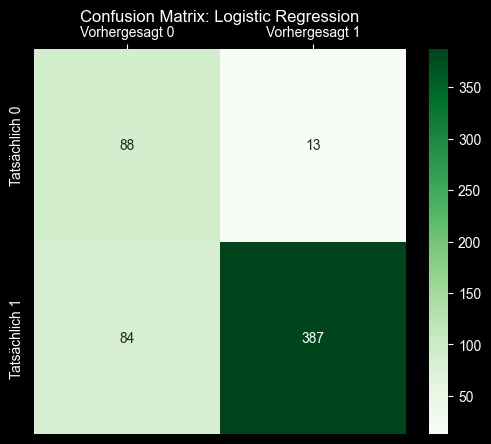

In [26]:
#'''
# Confusion Matrix ausgeben

# Matrix berechnen
cm_lr = confusion_matrix(y_test, y_pred_lr)

# Heatmap erstellen
plt.figure(figsize=(6, 5))
ax = sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens',
                 xticklabels=['Vorhergesagt 0', 'Vorhergesagt 1'],
                 yticklabels=['Tatsächlich 0', 'Tatsächlich 1'])
# Label und Ticks nach oben
ax.xaxis.set_label_position('top')
ax.xaxis.tick_top()
plt.title('Confusion Matrix: Logistic Regression', pad=20)
plt.show()
#'''

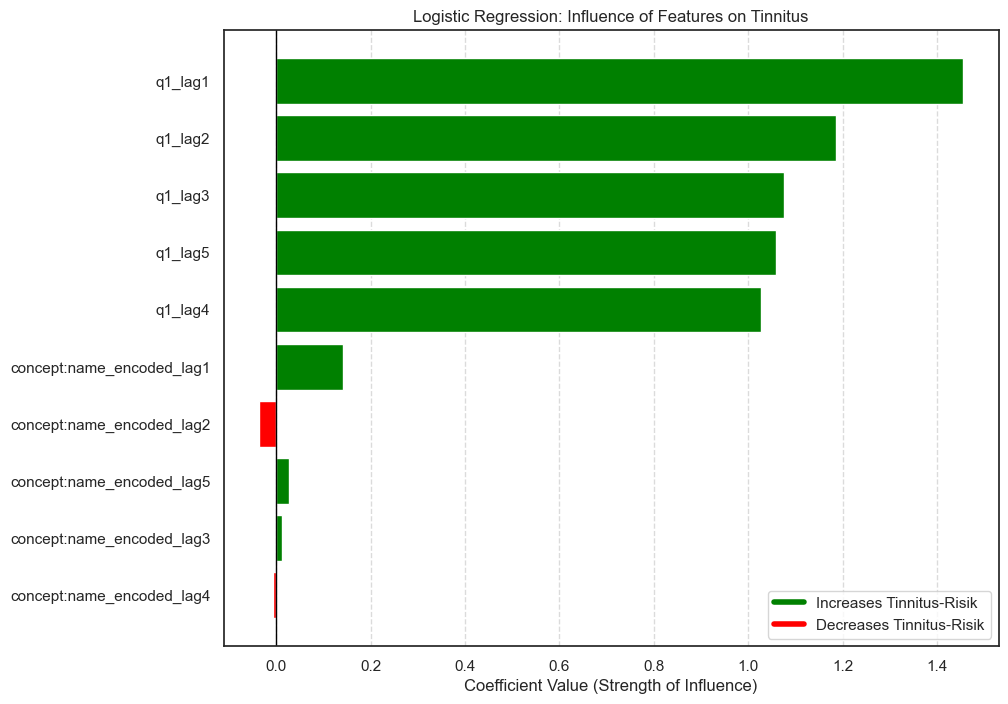

In [16]:
#'''
# schauen, was die Logistsche Regession genau gemacht hat

sns.set_theme(style="white")
# Koeffizienten extrahieren
coefficients = model_lr.coef_[0]
feature_names = X_train.columns

# In DataFrame packen für einfacheres Sortieren
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values(by='Abs_Coefficient', ascending=True).tail(30) # Top X Features

# Plot erstellen
plt.figure(figsize=(10, 8))
colors = ['red' if x < 0 else 'green' for x in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)

plt.axvline(x=0, color='black', linestyle='-', linewidth=1)
plt.xlabel('Coefficient Value (Strength of Influence)')
plt.title('Logistic Regression: Influence of Features on Tinnitus')
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Legende manuell hinzufügen
from matplotlib.lines import Line2D
custom_lines = [Line2D([0], [0], color='green', lw=4),
                Line2D([0], [0], color='red', lw=4)]
plt.legend(custom_lines, ['Increases Tinnitus-Risik', 'Decreases Tinnitus-Risik'])

plt.show()
#'''

## XG Boost

In [28]:
#'''
# Modell trainieren V1

# Initialisierung
model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    eval_metric='logloss'
)

# Training
model.fit(X_train, y_train)

# Vorhersage auf dem Testset
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1] # Wahrscheinlichkeiten für Klasse 1

# Evaluation
print("XG Boost Klassifikationsbericht:")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}")
#'''

XG Boost Klassifikationsbericht:
              precision    recall  f1-score   support

         0.0       0.66      0.66      0.66       101
         1.0       0.93      0.93      0.93       471

    accuracy                           0.88       572
   macro avg       0.79      0.79      0.79       572
weighted avg       0.88      0.88      0.88       572

ROC-AUC Score: 0.9114


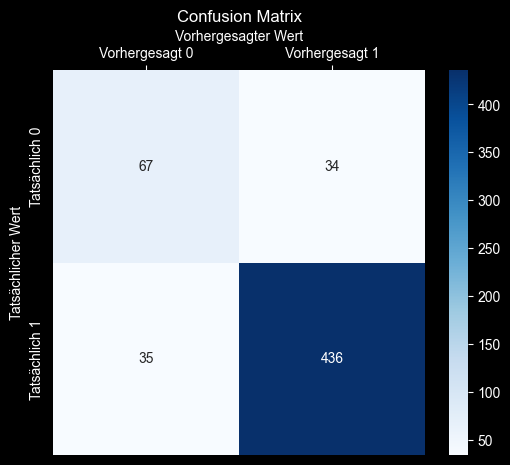

In [29]:
#'''
# Confusion Matrix ausgeben

# Matrix berechnen
cm = confusion_matrix(y_test, y_pred)

# Heatmap erstellen
plt.figure(figsize=(6, 5))
ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Vorhergesagt 0', 'Vorhergesagt 1'],
            yticklabels=['Tatsächlich 0', 'Tatsächlich 1'])

# Label und Ticks nach oben
ax.xaxis.set_label_position('top')
ax.xaxis.tick_top()

plt.ylabel('Tatsächlicher Wert')
plt.xlabel('Vorhergesagter Wert')
plt.title('Confusion Matrix')
plt.show()
#'''

In [30]:
'''
# -> je nach Modell kommen andere Feature Importances raus

# Modell trainieren V2 (mit scale_pos_weight)
# scale_pos_weight hilft, falls die Klassen (Tinnitus vs. kein Tinnitus) ungleich verteilt sind

# Berechnet das Verhältnis von 0 zu 1 von q1 für XGBoost.
def get_class_weights(y):
    count_0 = (y == 0).sum()
    count_1 = (y == 1).sum()

    print(f"Verteilung der Daten: Klasse 0 = {count_0}, Klasse 1 = {count_1}")

    # scale_pos_weight = count_neg / count_pos
    weight = count_0 / count_1
    print(f"Berechnetes scale_pos_weight für XGBoost: {weight:.4f}")

    return weight


from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

# Gewichtung berechnen
scale_pos = get_class_weights(y_train)

# Modell mit Gewichtung initialisieren
model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    scale_pos_weight=scale_pos, # Hier wird die Gewichtung angewendet
    eval_metric='logloss'
)

model.fit(X_train, y_train)

# Evaluation
from sklearn.metrics import f1_score, roc_auc_score
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# Loggen

experiment_logs = []
def log_experiment(params, metrics):
    log_entry = {'params': params, 'metrics': metrics}
    experiment_logs.append(log_entry)


log_experiment(
    params={'window_size': 10, 'max_depth': 5},
    metrics={
        'auc': roc_auc_score(y_test, y_proba),
        'f1': f1_score(y_test, y_pred)
    }
)
'''

'\n# -> je nach Modell kommen andere Feature Importances raus\n\n# Modell trainieren V2 (mit scale_pos_weight)\n# scale_pos_weight hilft, falls die Klassen (Tinnitus vs. kein Tinnitus) ungleich verteilt sind\n\n# Berechnet das Verhältnis von 0 zu 1 von q1 für XGBoost.\ndef get_class_weights(y):\n    count_0 = (y == 0).sum()\n    count_1 = (y == 1).sum()\n\n    print(f"Verteilung der Daten: Klasse 0 = {count_0}, Klasse 1 = {count_1}")\n\n    # scale_pos_weight = count_neg / count_pos\n    weight = count_0 / count_1\n    print(f"Berechnetes scale_pos_weight für XGBoost: {weight:.4f}")\n\n    return weight\n\n\nfrom xgboost import XGBClassifier\nfrom sklearn.metrics import classification_report, roc_auc_score\n\n# Gewichtung berechnen\nscale_pos = get_class_weights(y_train)\n\n# Modell mit Gewichtung initialisieren\nmodel = XGBClassifier(\n    n_estimators=100,\n    max_depth=5,\n    scale_pos_weight=scale_pos, # Hier wird die Gewichtung angewendet\n    eval_metric=\'logloss\'\n)\n\nmodel

In [31]:
'''
# zu: Modell trainieren V2

print(f"\nKlassifikationsbericht:")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}")
'''

'\n# zu: Modell trainieren V2\n\nprint(f"\nKlassifikationsbericht:")\nprint(classification_report(y_test, y_pred))\nprint(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}")\n'

In [ ]:
'''
# schauen, was XGBoost genau gemacht hat
import matplotlib.pyplot as plt
from xgboost import plot_importance

plot_importance(model, max_num_features=30) # Top X Features
plt.show()
#'''

In [33]:
# lag1 ist der letzte Eintrag vor dem zu Prognostizierenden. lag10 ist der 10. Eintrag vor dem zu Prognostizierenden.
# je größer "Importance Score", desto wichtiger ist dieser Wert für die Prognose.

## Random Forest

In [15]:
#'''
# Initialisierung
model_rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)

# Training
model_rf.fit(X_train, y_train)

# Vorhersage auf dem Testset
y_pred_rf = model_rf.predict(X_test)
y_proba_rf = model_rf.predict_proba(X_test)[:, 1]

# Evaluation
print("Random Forest Klassifikationsbericht:")
print(classification_report(y_test, y_pred_rf))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba_rf):.4f}")
#'''

Random Forest Klassifikationsbericht:
              precision    recall  f1-score   support

         0.0       0.79      0.61      0.69       112
         1.0       0.92      0.96      0.94       494

    accuracy                           0.90       606
   macro avg       0.85      0.79      0.81       606
weighted avg       0.89      0.90      0.89       606

ROC-AUC Score: 0.9089


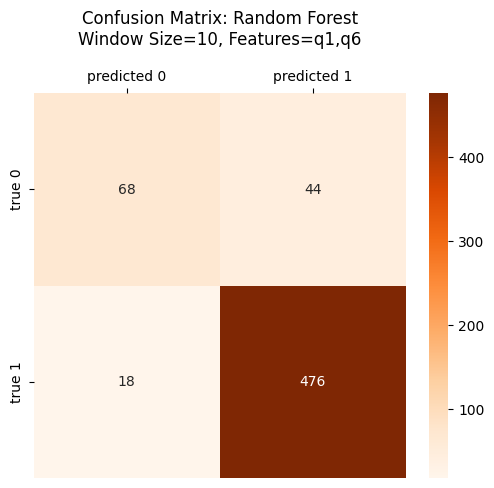

In [30]:
#'''
# Confusion Matrix ausgeben
plt.style.use('default')
# Matrix berechnen
cm_rf = confusion_matrix(y_test, y_pred_rf)

# Heatmap erstellen
plt.figure(figsize=(6, 5))
ax = sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges',
                 xticklabels=['predicted 0', 'predicted 1'],
                 yticklabels=['true 0', 'true 1'])
# Label und Ticks nach oben
ax.xaxis.set_label_position('top')
ax.xaxis.tick_top()
plt.title(f'Confusion Matrix: Random Forest\nWindow Size=10, Features=q1,q6\n', pad=20)
plt.show()
#'''

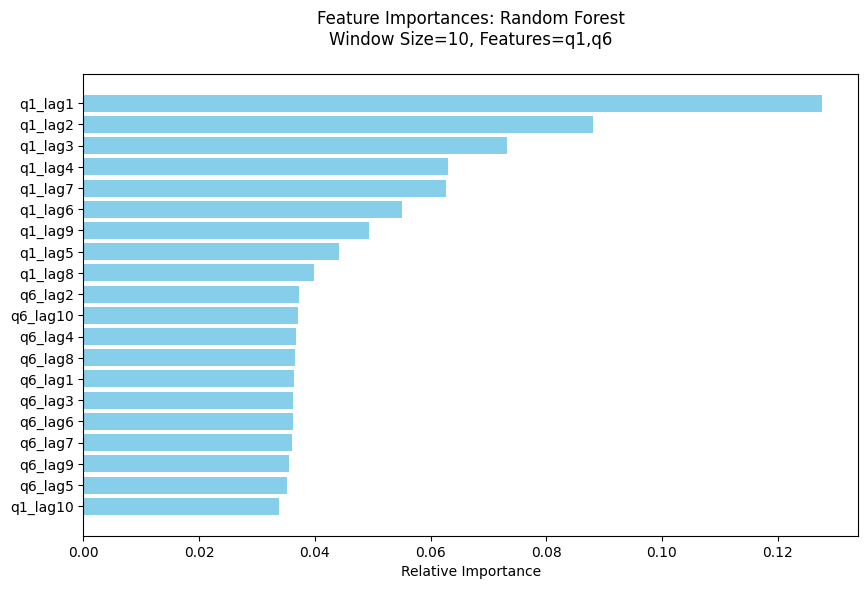

In [32]:
#'''
# schauen, was der Random Forest genau gemacht hat

# Feature Importance Plot (Ähnlich zu XGBoost)
importances = model_rf.feature_importances_
indices = np.argsort(importances)[-30:] # Top X Features

plt.figure(figsize=(10, 6))
plt.title('Feature Importances: Random Forest\nWindow Size=10, Features=q1,q6\n')
plt.barh(range(len(indices)), importances[indices], align='center', color='skyblue')
plt.yticks(range(len(indices)), [feature_cols[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()
#'''